##### Copyright 2026 Google LLC.

CSP Problem: Map Coloring

Solution:
WA -> Red
NT -> Green
SA -> Blue
Q -> Red
NSW -> Green
V -> Red
T -> Red


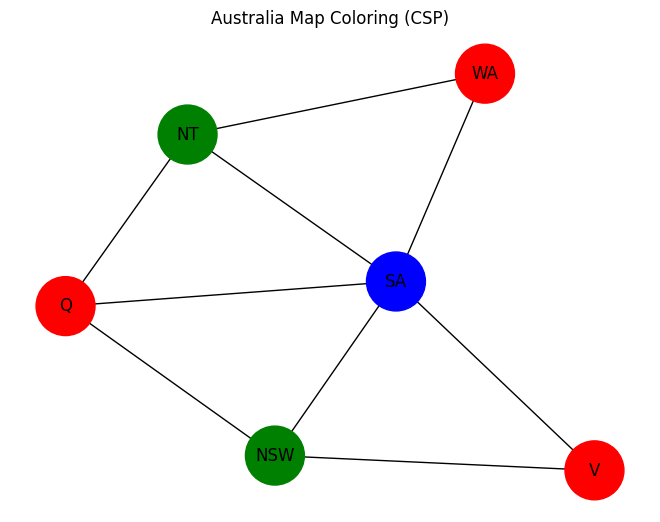


Constraints satisfied: True


In [7]:
# ============================================================
# AI Assignment 4: CSP Map Coloring (Modified Version)
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt

# States (variables)
states = ['WA', 'NT', 'SA', 'Q', 'NSW', 'V', 'T']

# Neighbour relationships
adjacent_states = {
    'WA': ['NT', 'SA'],
    'NT': ['WA', 'SA', 'Q'],
    'SA': ['WA', 'NT', 'Q', 'NSW', 'V'],
    'Q' : ['NT', 'SA', 'NSW'],
    'NSW': ['Q', 'SA', 'V'],
    'V': ['SA', 'NSW'],
    'T': []
}

# Colors (domain)
color_list = ['Red', 'Green', 'Blue']
domain_map = {s: color_list[:] for s in states}

# ---------------- VALIDATION ----------------
def check_valid(state, color, assigned):
    for neighbour in adjacent_states[state]:
        if neighbour in assigned and assigned[neighbour] == color:
            return False
    return True

# ---------------- BACKTRACKING ----------------
def solve_csp(assigned):
    if len(assigned) == len(states):
        return assigned

    # pick unassigned state
    current_state = next(s for s in states if s not in assigned)

    for col in domain_map[current_state]:
        if check_valid(current_state, col, assigned):
            assigned[current_state] = col

            result = solve_csp(assigned)
            if result:
                return result

            del assigned[current_state]  # backtrack

    return None

# ---------------- DRAW GRAPH ----------------
def display_map(solution):
    G = nx.Graph()

    for s in adjacent_states:
        for nb in adjacent_states[s]:
            G.add_edge(s, nb)

    pos = nx.spring_layout(G)

    color_map = []
    for node in G.nodes():
        if solution[node] == 'Red':
            color_map.append('red')
        elif solution[node] == 'Green':
            color_map.append('green')
        else:
            color_map.append('blue')

    nx.draw(G, pos,
            with_labels=True,
            node_color=color_map,
            node_size=1800)

    plt.title("Australia Map Coloring (CSP)")
    plt.show()

# ---------------- MAIN ----------------
if __name__ == "__main__":
    print("CSP Problem: Map Coloring")

    answer = solve_csp({})

    print("\nSolution:")
    if answer:
        for st, col in answer.items():
            print(f"{st} -> {col}")

        display_map(answer)

        # Check constraints
        valid = all(
            answer[s] != answer[n]
            for s in states
            for n in adjacent_states[s]
            if n in answer
        )

        print("\nConstraints satisfied:", valid)
    else:
        print("No solution found")